In [1]:
# Cell 1 — Install Dependencies
!pip install transformers torch torchvision pillow datasets huggingface_hub -q

In [2]:
# Cell 2 — Mount Google Drive (run once, saves everything persistently)
from google.colab import drive
drive.mount("/content/drive")

import os
SAVE_DIR = "/content/drive/MyDrive/MuseumCaption"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/MuseumCaption


In [3]:
# Cell 3 — HuggingFace Login via Colab Secrets
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))

In [4]:
# Cell 4 — Imports
import torch
import pickle
from PIL import Image
from transformers import (
    CLIPProcessor, CLIPModel,
    GPT2Tokenizer,
    BlipProcessor, BlipForConditionalGeneration
)
from datasets import load_dataset
import matplotlib.pyplot as plt

In [5]:
# Cell 5 — Device Setup
assert torch.cuda.is_available(), "Go to Runtime > Change runtime type > T4/A100 GPU"
device = "cuda"
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-40GB


In [6]:
# Cell 6 — Load CLIP (cache to Drive so it won't re-download)
CLIP_PATH = f"{SAVE_DIR}/clip_model"

if os.path.exists(CLIP_PATH):
    print("Loading CLIP from Drive cache...")
    clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(device)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
else:
    print("Downloading CLIP and saving to Drive...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model.save_pretrained(CLIP_PATH)
    clip_processor.save_pretrained(CLIP_PATH)

clip_model.eval()
print("CLIP ready.")

Loading CLIP from Drive cache...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP ready.


In [7]:
# Cell 7 — Load GPT-2 Tokenizer (caption preprocessing only; no generation)
GPT2_PATH = f"{SAVE_DIR}/gpt2_tokenizer"

if os.path.exists(GPT2_PATH):
    print("Loading GPT-2 tokenizer from Drive cache...")
    gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_PATH)
else:
    print("Downloading GPT-2 tokenizer and saving to Drive...")
    gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    gpt2_tokenizer.save_pretrained(GPT2_PATH)

gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
print("GPT-2 tokenizer ready.")

# ── Load BLIP (caption generation model) ──────────────────────────────────
BLIP_PATH = f"{SAVE_DIR}/blip_model"
BLIP_MODEL_ID = "Salesforce/blip-image-captioning-base"

if os.path.exists(BLIP_PATH):
    print("Loading BLIP from Drive cache...")
    blip_processor = BlipProcessor.from_pretrained(BLIP_PATH)
    blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_PATH).to(device)
else:
    print("Downloading BLIP and saving to Drive...")
    blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_ID)
    blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_ID).to(device)
    blip_processor.save_pretrained(BLIP_PATH)
    blip_model.save_pretrained(BLIP_PATH)

blip_model.eval()
print("BLIP ready.")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPT-2 tokenizer ready.
Loading BLIP from Drive cache...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BLIP ready.


In [8]:
# Cell 8 — Load & Cache Dataset (saves processed pairs to Drive as pickle)
DATA_PATH = f"{SAVE_DIR}/flickr30k_1k.pkl"

if os.path.exists(DATA_PATH):
    print("Loading dataset from Drive cache...")
    with open(DATA_PATH, "rb") as f:
        data = pickle.load(f)
    print(f"Loaded {len(data)} pairs from cache.")
else:
    print("Downloading Flickr30k and processing...")
    dataset = load_dataset("clip-benchmark/wds_flickr30k", split="test", trust_remote_code=False)
    data = []
    for item in dataset:
        img = item["jpg"].convert("RGB")
        caption = item["txt"].strip()
        if len(caption.split()) >= 5:
            data.append({"image": img, "caption": caption})
        if len(data) >= 1000:
            break
    with open(DATA_PATH, "wb") as f:
        pickle.dump(data, f)
    print(f"Saved {len(data)} pairs to Drive cache.")

Loading dataset from Drive cache...
Loaded 1000 pairs from cache.


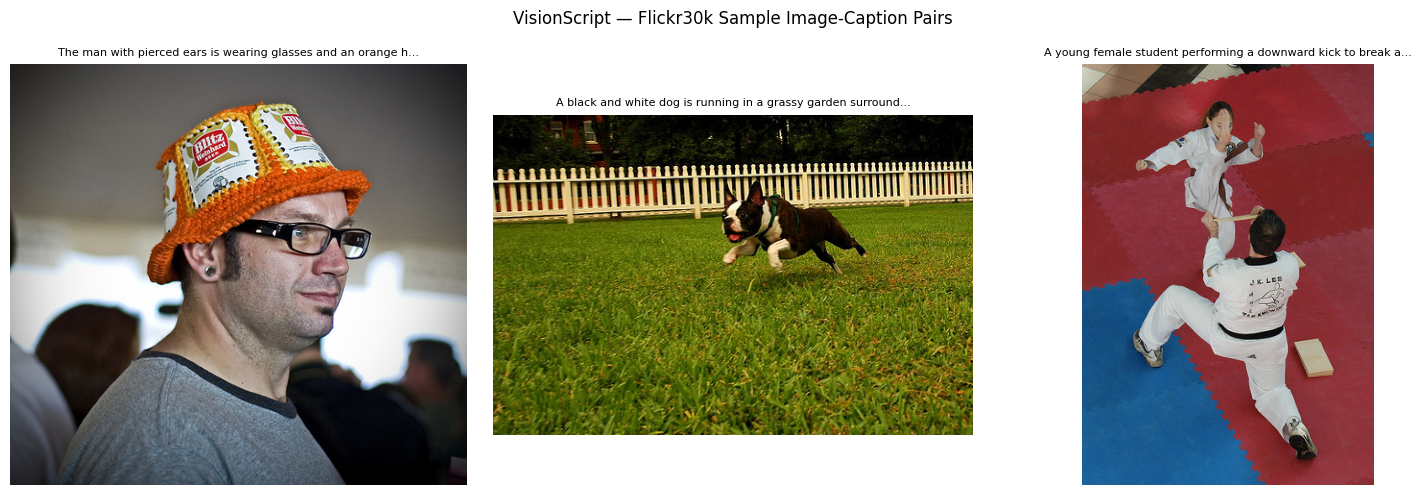

In [9]:
# Cell 9 — Preview 3 Sample Pairs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(data[i]["image"])
    axes[i].set_title(data[i]["caption"][:60] + "...", fontsize=8)
    axes[i].axis("off")
plt.suptitle("VisionScript — Flickr30k Sample Image-Caption Pairs", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Cell 10 — Helper: Extract CLIP Image Embedding
def get_image_embedding(img):
    inputs = clip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = clip_model.get_image_features(**inputs)
    if hasattr(emb, "pooler_output"):
        emb = emb.pooler_output
    elif hasattr(emb, "last_hidden_state"):
        emb = emb.last_hidden_state[:, 0, :]
    emb = emb.float()
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb  # shape: (1, 512)

In [11]:
# Cell 11 — Helper: Tokenize Caption with GPT-2
def tokenize_caption(caption, max_length=77):
    tokens = gpt2_tokenizer(
        caption,
        return_tensors="pt",
        max_length=max_length,
        truncation=True,
        padding="max_length"
    )
    return tokens

In [12]:
# Cell 12 — Helper: Generate Caption with BLIP (unconditional)
def generate_caption(img, max_new_tokens=50):
    """
    Generate a single natural-language caption for a PIL image using BLIP.
    No style prompts — pure unconditional captioning.
    """
    img = img.convert("RGB")
    inputs = blip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        output_ids = blip_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True
        )
    caption = blip_processor.decode(output_ids[0], skip_special_tokens=True)
    return caption

In [13]:
# Cell 13 — Compute & Cache All Embeddings (skip if already done)
EMB_PATH = f"{SAVE_DIR}/embeddings.pt"

if os.path.exists(EMB_PATH):
    print("Loading embeddings from Drive cache...")
    embeddings = torch.load(EMB_PATH)
    print(f"Loaded {len(embeddings)} embeddings.")
else:
    print("Computing embeddings for all 1k images...")
    embeddings = []
    for i, item in enumerate(data):
        emb = get_image_embedding(item["image"])
        embeddings.append(emb.cpu())  # store on CPU to save GPU memory
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/1000 done...")
    torch.save(embeddings, EMB_PATH)
    print(f"Saved {len(embeddings)} embeddings to Drive.")

Loading embeddings from Drive cache...
Loaded 1000 embeddings.


In [14]:
# Cell 14 — Verify Embedding + Tokenization on 1 Sample
img = data[0]["image"]
cap = data[0]["caption"]
emb = get_image_embedding(img)
tokens = tokenize_caption(cap)

print(f"Caption            : {cap}")
print(f"Token IDs          : {tokens['input_ids']}")
print(f"Token count        : {tokens['input_ids'].shape[1]}")
print(f"Embedding shape    : {emb.shape}")

Caption            : The man with pierced ears is wearing glasses and an orange hat.
A man with glasses is wearing a beer can crocheted hat.
A man with gauges and glasses is wearing a Blitz hat.
A man in an orange hat starring at something.
A man wears an orange hat and glasses.
Token IDs          : tensor([[  464,   582,   351, 41159, 11368,   318,  5762, 15232,   290,   281,
         10912,  6877,    13,   198,    32,   582,   351, 15232,   318,  5762,
           257,  6099,   460,  6763,  2395,  1513,  6877,    13,   198,    32,
           582,   351, 14885,  3212,   290, 15232,   318,  5762,   257, 29299,
          6877,    13,   198,    32,   582,   287,   281, 10912,  6877, 20495,
           379,  1223,    13,   198,    32,   582, 17326,   281, 10912,  6877,
           290, 15232,    13, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256]])
Token count        : 77
Embedding shape    : torch.Size([1, 512])


In [15]:
# Cell 15 — Run 5 Baseline Caption Test Runs
print("=" * 60)
print("VisionScript — Milestone 1: Baseline Caption Test Runs")
print("=" * 60)

results = []
for i in range(5):
    img       = data[i]["image"]
    original  = data[i]["caption"]
    generated = generate_caption(img)
    emb       = get_image_embedding(img)
    results.append({"original": original, "generated": generated})
    print(f"\n[{i+1}]")
    print(f"  Original   : {original}")
    print(f"  Generated  : {generated}")
    print(f"  Emb shape  : {emb.shape}")
    print("-" * 50)

# Save results to Drive
RESULTS_PATH = f"{SAVE_DIR}/baseline_results.pkl"
with open(RESULTS_PATH, "wb") as f:
    pickle.dump(results, f)
print(f"\nResults saved to {RESULTS_PATH}")

VisionScript — Milestone 1: Baseline Caption Test Runs

[1]
  Original   : The man with pierced ears is wearing glasses and an orange hat.
A man with glasses is wearing a beer can crocheted hat.
A man with gauges and glasses is wearing a Blitz hat.
A man in an orange hat starring at something.
A man wears an orange hat and glasses.
  Generated  : a man wearing a hat
  Emb shape  : torch.Size([1, 512])
--------------------------------------------------

[2]
  Original   : A black and white dog is running in a grassy garden surrounded by a white fence.
A Boston Terrier is running on lush green grass in front of a white fence.
A black and white dog is running through the grass.
A dog runs on the green grass near a wooden fence.
A Boston terrier is running in the grass.
  Generated  : a white picket fence
  Emb shape  : torch.Size([1, 512])
--------------------------------------------------

[3]
  Original   : A young female student performing a downward kick to break a board held by her K

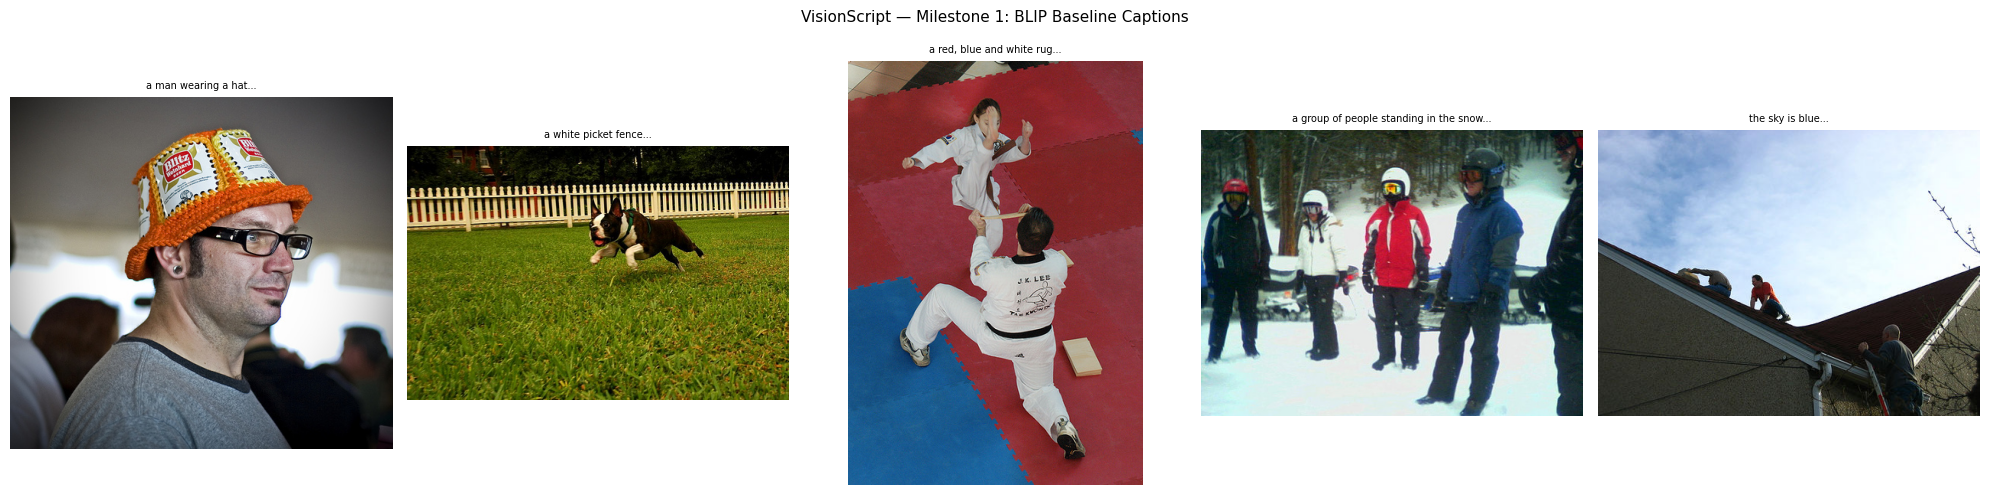

Plot saved to Drive.


In [16]:
# Cell 16 — Display 5 Images + Generated Captions
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    axes[i].imshow(data[i]["image"])
    cap = results[i]["generated"]
    axes[i].set_title(cap[:50] + "...", fontsize=7)
    axes[i].axis("off")
plt.suptitle("VisionScript — Milestone 1: BLIP Baseline Captions", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/baseline_captions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to Drive.")